# Exploratory Data Analysis: Roman Femurs

### Things to Remember:

* For adults: a 10-mm femur-length difference is roughly a one-inch difference in height.
* For males: Height = 2.32 × Femur Length + 655.3
* For females: Height = 2.47 × Femur Length + 541.0
* For males: a 400 mm femur = 5'2.3"
* For females: a 400 mm femur = 5'0.2"
* For males: a 450 mm femur = 5'6.9"
* For females: a 450 mm femur = 5'5.1"
* For males: a 500 mm femur = 5'11.5"
* For females: a 500 mm femer = 5'9.9"


### The Roman Empire Around the Year 200     

![The Roman Empire Around the Year 200 Map](2024-09-13-econ-135/roman_empire_200.png)

### The Province Britannia

![The Province Britanna Map](2024-09-13-econ-135/britannia.png)

### The Northwest European Provinces

![The Northwest European Provinces Map](2024-09-13-econ-135/northwesteurope.png)

In [1]:
provinces = [
    "Achaea", "Aegyptus", "Africa", "Alpes Cottiae", "Alpes Maritimae", "Alpes Poeninae",
    "Arabia Petrae", "Armenia", "Asia", "Assyria", "Bithynia et Pontus", "Britannia (Inf. et Sup.)",
    "Cappadocia", "Cilicia", "Corsica et Sardinia", "Creta et Cyrenaica", "Cyprus", "Dacia",
    "Dalmatia", "Epirus", "Galatia", "Gallia Aquitania", "Gallia Belgica", "Gallia Lugdunensis",
    "Gallia Narbonensis", "Germania Inferior", "Germania Superior", "Hispania Baetica",
    "Hispania Tarraconensis", "Italia", "Iudaea", "Lusitania", "Lycia et Pamphylia", "Macedonia",
    "Mauretania Caesariensis", "Mauretania Tingitana", "Mesopotamia", "Moesia Inferior",
    "Moesia Superior", "Noricum", "Pannonia Inferior", "Pannonia Superior", "Raetia", "Sicilia",
    "Syria", "Taurica", "Thracia"
]

numbered_provinces = {i+1: province for i, province in enumerate(provinces)}


import pandas as pd

# Create a DataFrame from the numbered provinces
numbered_provinces_df = pd.DataFrame(list(numbered_provinces.items()), columns=["Number", "Province"])

numbered_provinces_df

,Number,Province
0,1,Achaea
1,2,Aegyptus
2,3,Africa
3,4,Alpes Cottiae
4,5,Alpes Maritimae
5,6,Alpes Poeninae
6,7,Arabia Petrae
7,8,Armenia
8,9,Asia
9,10,Assyria


In [2]:
import pandas as pd

df = pd.read_csv('2024-09-13-econ-135/roman_femurs.csv')

df.head()

,Femur,Province,Sex,WesternMediterranean,GreekEast,SouthEastEurope,NorthWestEurope,Date,Italy
0,400.92,30,0,1,0,0,0,800,1
1,401.17,30,0,1,0,0,0,800,1
2,400.68,30,0,1,0,0,0,800,1
3,400.38,30,0,1,0,0,0,800,1
4,400.48,30,0,1,0,0,0,800,1


In [3]:
len(df)

38031

In [4]:
type(numbered_provinces)

dict

In [5]:
df['ProvinceName'] = df['Province'].map(numbered_provinces)

In [6]:
df.head()

,Femur,Province,Sex,WesternMediterranean,GreekEast,SouthEastEurope,NorthWestEurope,Date,Italy,ProvinceName
0,400.92,30,0,1,0,0,0,800,1,Italia
1,401.17,30,0,1,0,0,0,800,1,Italia
2,400.68,30,0,1,0,0,0,800,1,Italia
3,400.38,30,0,1,0,0,0,800,1,Italia
4,400.48,30,0,1,0,0,0,800,1,Italia


In [7]:
category_counts = df['ProvinceName'].value_counts()
print(category_counts)

ProvinceName
Britannia (Inf. et Sup.)    9727
Pannonia Superior           4976
Italia                      4817
Pannonia Inferior           4296
Raetia                      2307
Germania Superior           1935
Gallia Lugdunensis          1761
Gallia Belgica              1692
Iudaea                      1227
Cyprus                      1002
Noricum                      912
Hispania Tarraconensis       626
Corsica et Sardinia          471
Achaea                       434
Africa                       247
Gallia Narbonensis           191
Syria                        157
Gallia Aquitania             140
Germania Inferior            138
Lusitania                    137
Macedonia                    125
Alpes Poeninae               122
Cappadocia                   114
Mauretania Caesariensis       92
Dalmatia                      82
Aegyptus                      68
Galatia                       62
Hispania Baetica              44
Sicilia                       43
Asia                          

In [8]:
df_pannonia_superior = df[df['ProvinceName'] == 'Pannonia Superior']

/tmp/ipykernel_100/3901428762.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pannonia_superior['Date_bin'] = pd.cut(df_pannonia_superior['Date'], bins)
/tmp/ipykernel_100/3901428762.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_pannonia_superior.groupby('Date_bin')['Femur'].mean().reset_index()


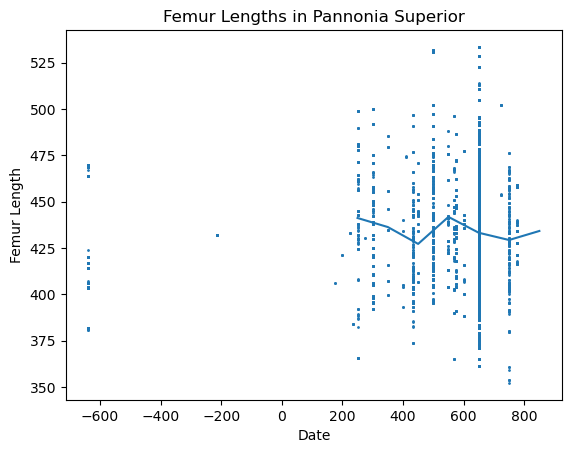

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df_pannonia_superior['Date'], df_pannonia_superior['Femur'], s=1)

bins = range(df_pannonia_superior['Date'].min(), df_pannonia_superior['Date'].max() + 100, 100)
df_pannonia_superior['Date_bin'] = pd.cut(df_pannonia_superior['Date'], bins)

grouped_data = df_pannonia_superior.groupby('Date_bin')['Femur'].mean().reset_index()

plt.plot(-550+100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Lengths in Pannonia Superior')
plt.show()


plt.show()

In [10]:
df_germania_superior = df[df['ProvinceName'] == 'Germania Superior']

/tmp/ipykernel_100/4086171281.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_germania_superior['Date_bin'] = pd.cut(df_germania_superior['Date'], bins)
/tmp/ipykernel_100/4086171281.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_germania_superior.groupby('Date_bin')['Femur'].mean().reset_index()


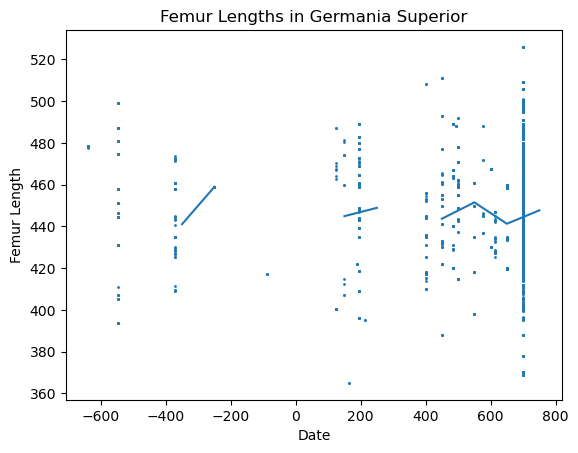

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df_germania_superior['Date'], df_germania_superior['Femur'], s=1)

bins = range(df_germania_superior['Date'].min(), df_germania_superior['Date'].max() + 100, 100)
df_germania_superior['Date_bin'] = pd.cut(df_germania_superior['Date'], bins)

grouped_data = df_germania_superior.groupby('Date_bin')['Femur'].mean().reset_index()

plt.plot(-550+100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Lengths in Germania Superior')
plt.show()


plt.show()

In [12]:
df_britannia = df[df['ProvinceName'] == 'Britannia (Inf. et Sup.)']

In [13]:
df_britannia

,Femur,Province,Sex,WesternMediterranean,GreekEast,SouthEastEurope,NorthWestEurope,Date,Italy,ProvinceName
11254,434.36,12,0,0,0,0,1,467,0,Britannia (Inf. et Sup.)
11255,434.60,12,0,0,0,0,1,467,0,Britannia (Inf. et Sup.)
11256,435.19,12,0,0,0,0,1,467,0,Britannia (Inf. et Sup.)
11257,435.39,12,0,0,0,0,1,467,0,Britannia (Inf. et Sup.)
11258,436.02,12,0,0,0,0,1,467,0,Britannia (Inf. et Sup.)
...,...,...,...,...,...,...,...,...,...,...
37919,424.00,12,1,0,0,0,1,450,0,Britannia (Inf. et Sup.)
37920,424.00,12,1,0,0,0,1,450,0,Britannia (Inf. et Sup.)
37921,424.00,12,1,0,0,0,1,450,0,Britannia (Inf. et Sup.)
37922,424.00,12,1,0,0,0,1,450,0,Britannia (Inf. et Sup.)


In [14]:
df_britannia = df_britannia.drop(columns=['ProvinceName'])

In [15]:
df_britannia.head()

,Femur,Province,Sex,WesternMediterranean,GreekEast,SouthEastEurope,NorthWestEurope,Date,Italy
11254,434.36,12,0,0,0,0,1,467,0
11255,434.60,12,0,0,0,0,1,467,0
11256,435.19,12,0,0,0,0,1,467,0
11257,435.39,12,0,0,0,0,1,467,0
11258,436.02,12,0,0,0,0,1,467,0


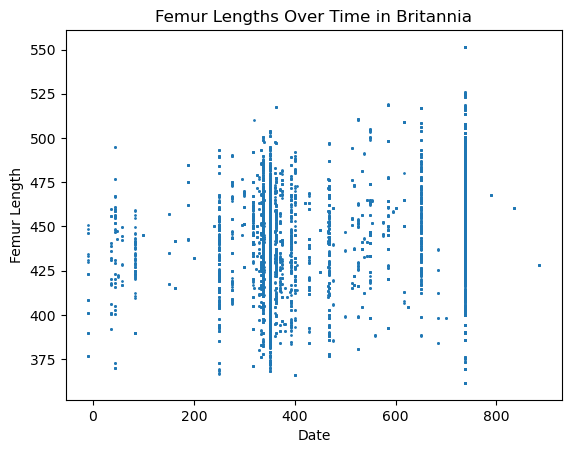

In [16]:
import matplotlib.pyplot as plt

plt.scatter(df_britannia['Date'], df_britannia['Femur'], s=1)

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Lengths Over Time in Britannia')

# Display the plot
plt.show()

/tmp/ipykernel_100/3957551306.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_britannia.groupby('Date_bin')['Femur'].mean().reset_index()


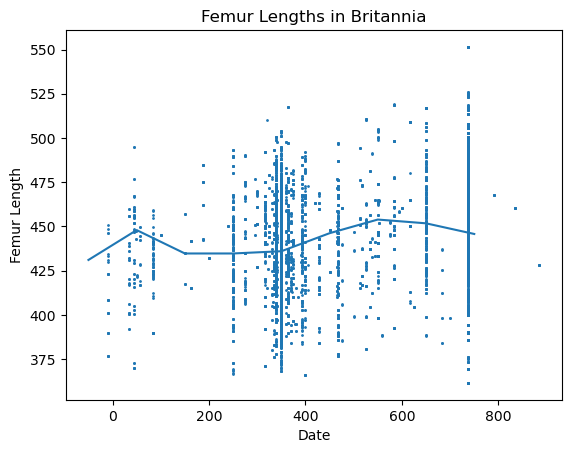

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df_britannia['Date'].min(), df_britannia['Date'].max() + 100, 100)
df_britannia['Date_bin'] = pd.cut(df_britannia['Date'], bins)

grouped_data = df_britannia.groupby('Date_bin')['Femur'].mean().reset_index()

plt.scatter(df_britannia['Date'], df_britannia['Femur'], s=1)
plt.plot(-50+100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Lengths in Britannia')
plt.show()

In [18]:
df_WesternMediterranean = df[df['WesternMediterranean'] == 1]
df_GreekEast = df[df['GreekEast'] == 1]
df_NorthWestEurope = df[df['NorthWestEurope'] == 1]
df_SouthEastEurope = df[df['SouthEastEurope'] == 1]

In [19]:
df_iudaea = df[df['ProvinceName'] == 'Iudaea']

/tmp/ipykernel_100/2469083078.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_iudaea['Date_bin'] = pd.cut(df_iudaea['Date'], bins)
/tmp/ipykernel_100/2469083078.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_iudaea.groupby('Date_bin')['Femur'].mean().reset_index()


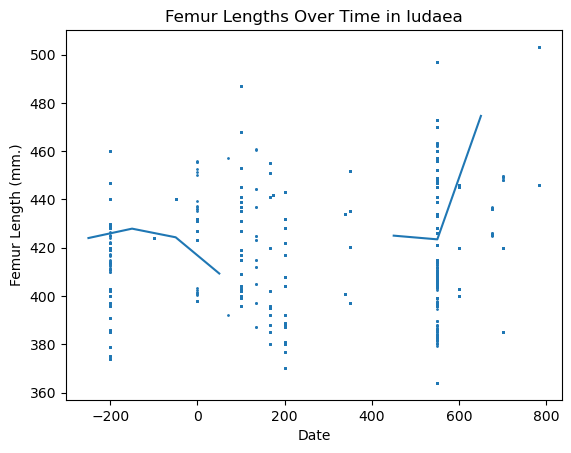

In [20]:
import matplotlib.pyplot as plt

plt.scatter(df_iudaea['Date'], df_iudaea['Femur'], s=1)

bins = range(df_iudaea['Date'].min(), df_iudaea['Date'].max() + 100, 100)
df_iudaea['Date_bin'] = pd.cut(df_iudaea['Date'], bins)

grouped_data = df_iudaea.groupby('Date_bin')['Femur'].mean().reset_index()

plt.plot(-250 + 100 * grouped_data.index, grouped_data['Femur'])

plt.xlabel('Date')
plt.ylabel('Femur Length (mm.)')
plt.title('Femur Lengths Over Time in Iudaea')

# Display the plot
plt.show()

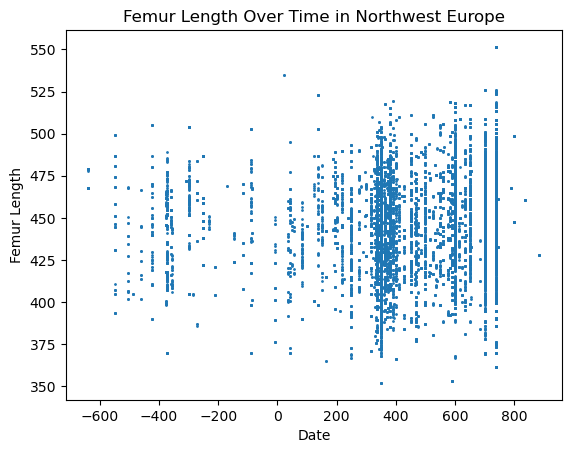

In [21]:
import matplotlib.pyplot as plt

plt.scatter(df_NorthWestEurope['Date'], df_NorthWestEurope['Femur'], s=1)

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Length Over Time in Northwest Europe')

# Display the plot
plt.show()

/tmp/ipykernel_100/2898305382.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_NorthWestEurope['Date_bin'] = pd.cut(df_NorthWestEurope['Date'], bins)
/tmp/ipykernel_100/2898305382.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_NorthWestEurope.groupby('Date_bin')['Femur'].mean().reset_index()


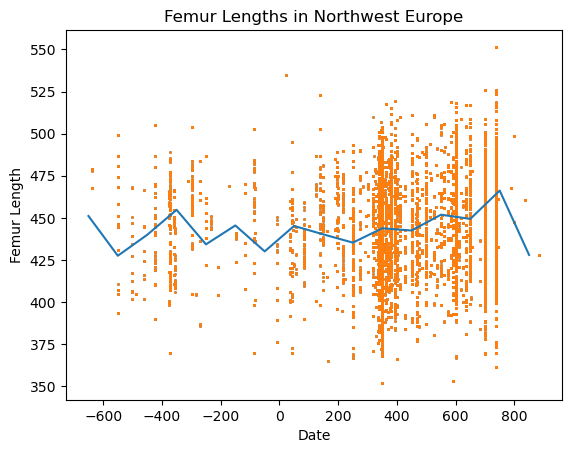

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df_NorthWestEurope['Date'].min(), df_NorthWestEurope['Date'].max() + 100, 100)
df_NorthWestEurope['Date_bin'] = pd.cut(df_NorthWestEurope['Date'], bins)

plt.scatter(df_NorthWestEurope['Date'], df_NorthWestEurope['Femur'], s=1)
grouped_data = df_NorthWestEurope.groupby('Date_bin')['Femur'].mean().reset_index()


plt.scatter(df_NorthWestEurope['Date'], df_NorthWestEurope['Femur'], s=1)
plt.plot(-650 + 100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Lengths in Northwest Europe')
plt.show()

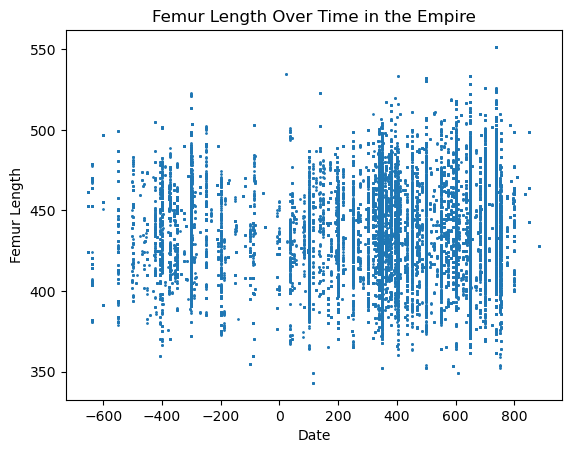

In [23]:
import matplotlib.pyplot as plt

plt.scatter(df['Date'], df['Femur'], s=1)

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Length Over Time in the Empire')

# Display the plot
plt.show()

/tmp/ipykernel_100/3260082040.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df.groupby('Date_bin')['Femur'].mean().reset_index()


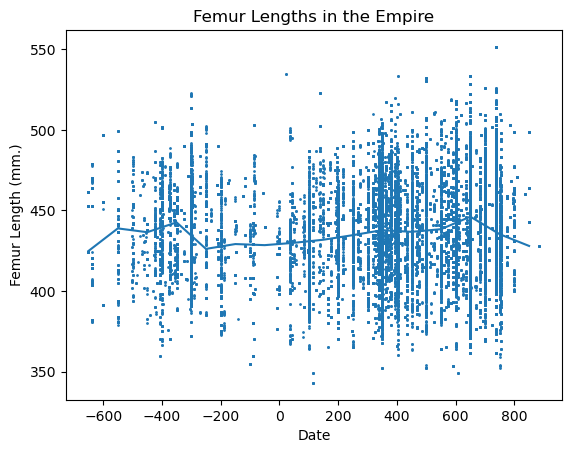

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df['Date'].min(), df['Date'].max() + 100, 100)
df['Date_bin'] = pd.cut(df['Date'], bins)

grouped_data = df.groupby('Date_bin')['Femur'].mean().reset_index()


plt.scatter(df['Date'], df['Femur'], s=1)
plt.plot(-650 + 100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('Date')
plt.ylabel('Femur Length (mm.)')
plt.title('Femur Lengths in the Empire')
plt.show()

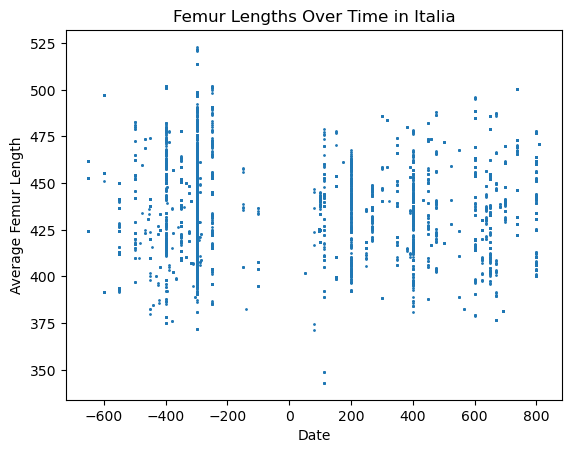

In [25]:
df_italia = df[df['ProvinceName'] == 'Italia']

import matplotlib.pyplot as plt

plt.scatter(df_italia['Date'], df_italia['Femur'], s=1)

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Average Femur Length')
plt.title('Femur Lengths Over Time in Italia')

# Display the plot
plt.show()

/tmp/ipykernel_100/2063305941.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_italia['Date_bin'] = pd.cut(df_italia['Date'], bins)
/tmp/ipykernel_100/2063305941.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_italia.groupby('Date_bin')['Femur'].mean().reset_index()


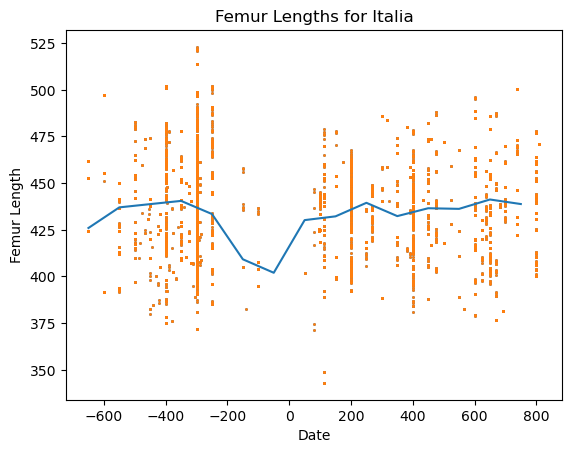

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df_italia['Date'].min(), df_italia['Date'].max() + 100, 100)
df_italia['Date_bin'] = pd.cut(df_italia['Date'], bins)

grouped_data = df_italia.groupby('Date_bin')['Femur'].mean().reset_index()

plt.scatter(df_italia['Date'], df_italia['Femur'], s=1)
plt.scatter(df_italia['Date'], df_italia['Femur'], s=1)
plt.plot(-650 + 100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('Date')
plt.ylabel('Femur Length')
plt.title('Femur Lengths for Italia')
plt.show()

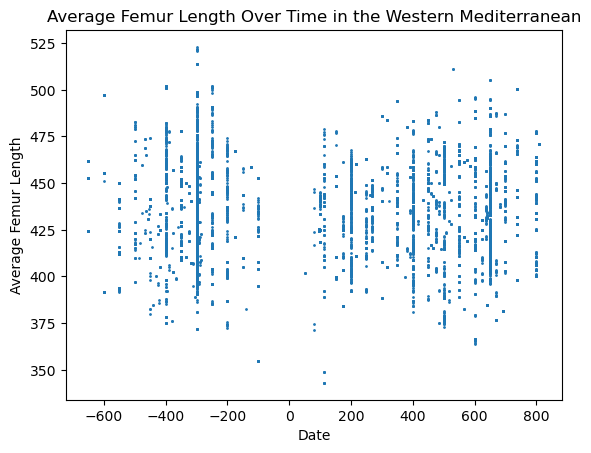

In [27]:
import matplotlib.pyplot as plt

plt.scatter(df_WesternMediterranean['Date'], df_WesternMediterranean['Femur'], s=1)

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Average Femur Length')
plt.title('Average Femur Length Over Time in the Western Mediterranean')

# Display the plot
plt.show()

/tmp/ipykernel_100/1046845635.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WesternMediterranean['Date_bin'] = pd.cut(df_WesternMediterranean['Date'], bins)
/tmp/ipykernel_100/1046845635.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_WesternMediterranean.groupby('Date_bin')['Femur'].mean().reset_index()


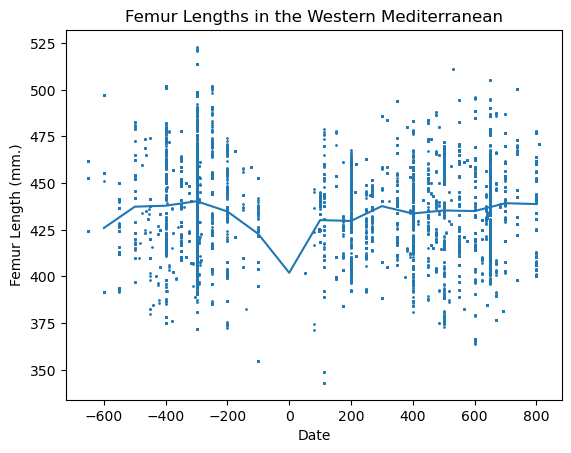

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df_WesternMediterranean['Date'].min(), df_WesternMediterranean['Date'].max() + 100, 100)
df_WesternMediterranean['Date_bin'] = pd.cut(df_WesternMediterranean['Date'], bins)

grouped_data = df_WesternMediterranean.groupby('Date_bin')['Femur'].mean().reset_index()

plt.scatter(df_WesternMediterranean['Date'], df_WesternMediterranean['Femur'], s=1)
plt.plot(-600 + 100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('Date')
plt.ylabel('Femur Length (mm.)')
plt.title('Femur Lengths in the Western Mediterranean')
plt.show()

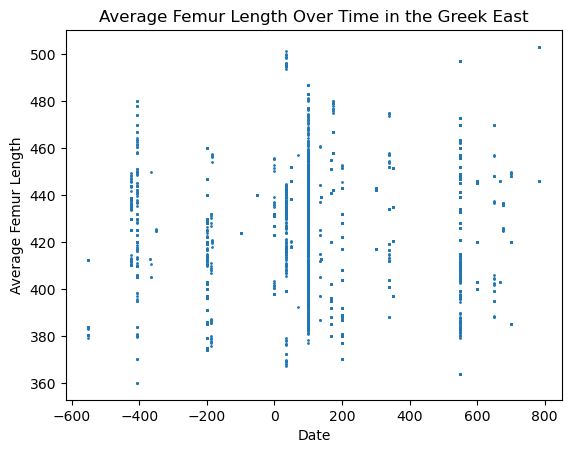

In [29]:
import matplotlib.pyplot as plt

plt.scatter(df_GreekEast['Date'], df_GreekEast['Femur'], s=1)

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Average Femur Length')
plt.title('Average Femur Length Over Time in the Greek East')

# Display the plot
plt.show()

/tmp/ipykernel_100/417790663.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_GreekEast['Date_bin'] = pd.cut(df_GreekEast['Date'], bins)
/tmp/ipykernel_100/417790663.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_GreekEast.groupby('Date_bin')['Femur'].mean().reset_index()


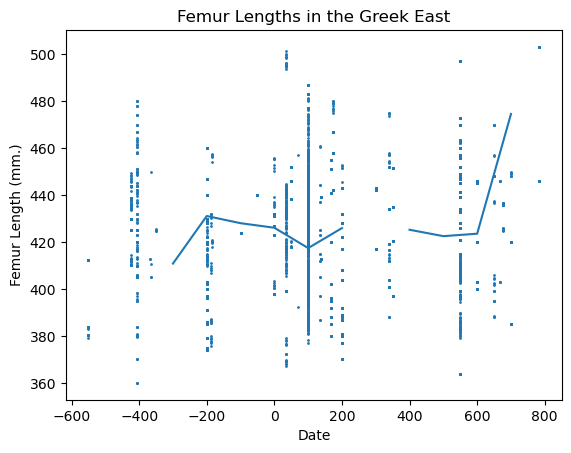

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df_GreekEast['Date'].min(), df_GreekEast['Date'].max() + 100, 100)
df_GreekEast['Date_bin'] = pd.cut(df_GreekEast['Date'], bins)

grouped_data = df_GreekEast.groupby('Date_bin')['Femur'].mean().reset_index()

plt.scatter(df_GreekEast['Date'], df_GreekEast['Femur'], s=1)
plt.plot(-600 + 100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('Date')
plt.ylabel('Femur Length (mm.)')
plt.title('Femur Lengths in the Greek East')
plt.show()

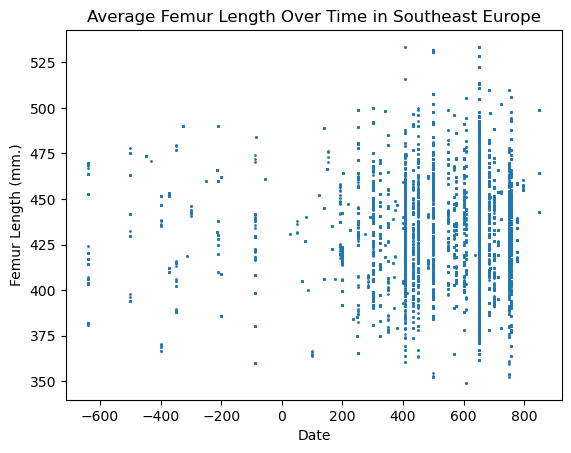

In [31]:
import matplotlib.pyplot as plt

plt.scatter(df_SouthEastEurope['Date'], df_SouthEastEurope['Femur'], s=1)

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Femur Length (mm.)')
plt.title('Average Femur Length Over Time in Southeast Europe')

# Display the plot
plt.show()

/tmp/ipykernel_100/1638312450.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_SouthEastEurope['Date_bin'] = pd.cut(df_SouthEastEurope['Date'], bins)
/tmp/ipykernel_100/1638312450.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df_SouthEastEurope.groupby('Date_bin')['Femur'].mean().reset_index()


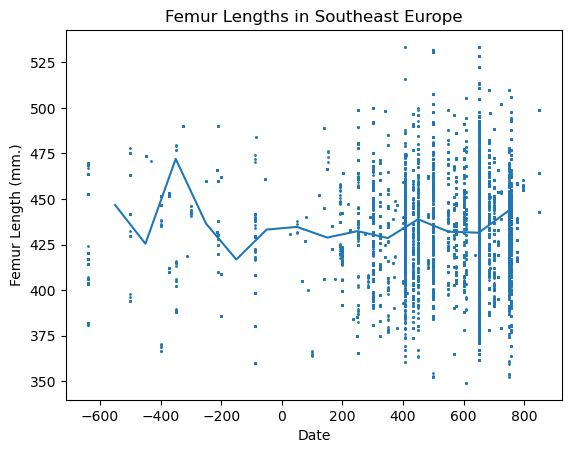

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

bins = range(df_SouthEastEurope['Date'].min(), df_SouthEastEurope['Date'].max() + 100, 100)
df_SouthEastEurope['Date_bin'] = pd.cut(df_SouthEastEurope['Date'], bins)

grouped_data = df_SouthEastEurope.groupby('Date_bin')['Femur'].mean().reset_index()

plt.scatter(df_SouthEastEurope['Date'], df_SouthEastEurope['Femur'], s=1)
plt.plot(-650 + 100 * grouped_data.index, grouped_data['Femur'])
plt.xlabel('Date')
plt.ylabel('Femur Length (mm.)')
plt.title('Femur Lengths in Southeast Europe')
plt.show()